In [8]:
!pip install -q torch torchvision torchaudio grad-cam neo4j langgraph langchain-core langchain-community gradio

In [9]:
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# 1. Define Diagnostic Labels
DIAGNOSTIC_CLASSES = [
    "Mild Demented",
    "Moderate Demented",
    "Non-Demented",
    "Very Mild Demented",
]

In [11]:
# 2. Load Vision Backbone (Modify with your own weights/Capsule Network checkpoint)
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(DIAGNOSTIC_CLASSES))
model.eval().to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
#Preprocessing Pipeline

transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize(
           mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )
    ]
)

# def analyze_mri_scan(pil_img):
#   rgb_img = np.float32(pil_img.convert("RGB"))/255.0
#   input_tensor = transform(pil_img.convert("RGB")).unsqueeze(0).to(device)


#   with torch.no_grad():
#     outputs = model(input_tensor)
#     probabilities = torch.softmax(outputs,dim=1).cpu().numpy()[0]
#     pred_idx = int(np.argmax(probabilities))
#     pred_class = DIAGNOSTIC_CLASSES[pred_idx]
#     confidence = float(probabilities[pred_idx])


# # Grad-CAM Explainability (Target layer: layer4[-1])
#   target_layers = [model.layer4[-1]]
#   targets = [ClassifierOutputTarget(pred_idx)]
#   with GradCAM(model=model, target_layers=target_layers) as cam:
#     grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
#     visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#   return pred_class, confidence, visualization



In [13]:
import cv2
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

TARGET_SIZE = (224, 224)  # Ensure this matches your transform.Resize


def analyze_mri_scan(pil_img):
  # 1. Standardize the PIL image to RGB and the model's exact target dimensions
  pil_resized = pil_img.convert("RGB").resize(TARGET_SIZE)

  # 2. Prepare the background image: float32, normalized to [0, 1], shape (224, 224, 3)
  rgb_img = np.float32(pil_resized) / 255.0

  # 3. Create the model input tensor
  input_tensor = transform(pil_resized).unsqueeze(0).to(device)

  # 4. Model Prediction
  with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probabilities))
    pred_class = DIAGNOSTIC_CLASSES[pred_idx]
    confidence = float(probabilities[pred_idx])

  # 5. Grad-CAM Explainability
  target_layers = [model.layer4[-1]]
  targets = [ClassifierOutputTarget(pred_idx)]

  with GradCAM(model=model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Ensure grayscale_cam matches rgb_img dimensions exactly
    if grayscale_cam.shape != rgb_img.shape[:2]:
      grayscale_cam = cv2.resize(
          grayscale_cam, (TARGET_SIZE[1], TARGET_SIZE[0])
      )

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

  return pred_class, confidence, visualization

In [18]:
from neo4j import GraphDatabase

# Paste your AuraDB credentials here:
# NEO4J_URI = "neo4j+s://<YOUR-INSTANCE-ID>.databases.neo4j.io"
# NEO4J_USER = "neo4j"
# NEO4J_PASSWORD = "<YOUR-PASSWORD>"

NEO4J_URI="neo4j+s://70bbdf04.databases.neo4j.io"
NEO4J_USERNAME="70bbdf04"
NEO4J_PASSWORD="CwwL-tkYwSfJc88URK7wwqEX3WCjTmGtloz81Kugg0E"


driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))


def populate_clinical_kg():
  cypher_queries = [
      """
        MERGE (d:Diagnosis {name: 'Very Mild Demented'})
        MERGE (t1:BiomarkerTest {name: 'Plasma p-tau217 & Amyloid-beta 42/40 ratio'})
        MERGE (t2:CognitiveTest {name: 'Montreal Cognitive Assessment (MoCA)'})
        MERGE (rx:Therapy {name: 'Lecanemab / Donepezil Evaluation'})
        MERGE (c:Contraindication {name: 'Check ApoE-e4 status for ARIA risk'})

        MERGE (d)-[:RECOMMENDED_TEST]->(t1)
        MERGE (d)-[:RECOMMENDED_TEST]->(t2)
        MERGE (d)-[:CONSIDER_THERAPY]->(rx)
        MERGE (rx)-[:CRITICAL_WARNING]->(c);
        """,
      """
        MERGE (d:Diagnosis {name: 'Moderate Demented'})
        MERGE (t:CognitiveTest {name: 'MMSE Assessment & Caregiver Burden Scale'})
        MERGE (rx:Therapy {name: 'Memantine + Donepezil Combination Therapy'})
        MERGE (c:Contraindication {name: 'Cardiac conduction monitoring'})

        MERGE (d)-[:RECOMMENDED_TEST]->(t)
        MERGE (d)-[:CONSIDER_THERAPY]->(rx)
        MERGE (rx)-[:CRITICAL_WARNING]->(c);
        """,
  ]
  with driver.session() as session:
    for query in cypher_queries:
      session.run(query)
  print("Clinical Knowledge Graph seeded successfully.")


# # Run seeding
populate_clinical_kg()

Clinical Knowledge Graph seeded successfully.


In [19]:
from typing import Any, Dict, TypedDict
from langgraph.graph import END, StateGraph

# Define the Shared Agent State
class ClinicalState(TypedDict):
  image_input : Any
  diagnosis :str
  confidence : float
  cam_heatmap : Any
  retrieved_guidelines : Dict[str,Any]
  final_clinical_report : str

# 2. Node : Vision Agent
def vision_agent(state: ClinicalState):
  img = state["image_input"]
  pred_class, conf, heatmap = analyze_mri_scan(img)
  return{
      "diagnosis" :pred_class,
      "confidence" : conf,
      "cam_heatmap" : heatmap
  }


In [20]:
# 3. Node: Neo4j Graph Retrieval Agent
def graph_retrieval_agent(state: ClinicalState):
  diagnosis = state["diagnosis"]

  cypher = """
    MATCH (d:Diagnosis {name: $diag})-[:RECOMMENDED_TEST]->(t)
    OPTIONAL MATCH (d)-[:CONSIDER_THERAPY]->(rx)
    OPTIONAL MATCH (rx)-[:CRITICAL_WARNING]->(c)
    RETURN collect(DISTINCT t.name) AS tests,
           collect(DISTINCT rx.name) AS therapies,
           collect(DISTINCT c.name) AS warnings
    """
  with driver.session() as session:
    result = session.run(cypher, diag=diagnosis).single()
    guidelines = {
        "tests": result["tests"] if result else [],
        "therapies": result["therapies"] if result else [],
        "warnings": result["warnings"] if result else [],
    }

  return {"retrieved_guidelines": guidelines}



In [21]:
#4. Node Clinical Synthesis Agent
def synthesis_agent(state :ClinicalState):
  diag = state["diagnosis"]
  conf = state["confidence"]
  guides = state["retrieved_guidelines"]

  report = f"""
### 🩺 Automated Clinical Decision Support Report
* **Diagnostic Prediction:** {diag} (Confidence: {conf*100:.2f}%)
* **Visual Biomarker Attribution:** Grad-CAM saliency generated on cortical & ventricular regions.

#### 📋 Evidence-Based Next Steps (Retrieved via Neo4j):
* **Recommended Diagnostic Tests:** {', '.join(guides.get('tests', ['N/A']))}
* **Therapeutic Considerations:** {', '.join(guides.get('therapies', ['N/A']))}
* **⚠️ Critical Safety & Contraindication Warnings:** {', '.join(guides.get('warnings', ['None']))}
"""
  return {"final_clinical_report": report}


In [22]:
#5. Compile LangGraph workflow

workflow = StateGraph(ClinicalState)
workflow.add_node("vision_agent",vision_agent)
workflow.add_node("graph_retrieval_agent",graph_retrieval_agent)
workflow.add_node("synthesis_agent",synthesis_agent)

workflow.set_entry_point("vision_agent")
workflow.add_edge("vision_agent","graph_retrieval_agent")
workflow.add_edge("graph_retrieval_agent","synthesis_agent")
workflow.add_edge("synthesis_agent",END)

clinical_app = workflow.compile()

#

In [ ]:
import gradio as gr

def run_pipeline(input_image):
  initial_state ={"image_input":input_image}

  result = clinical_app.invoke(initial_state)
  return result["cam_heatmap"], result["final_clinical_report"]

In [ ]:
demo = gr.Interface(
    fn=run_pipeline,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Scan (Axial View)"),
    outputs=[
        gr.Image(label="Explainable AI (Grad-CAM Heatmap)"),
        gr.Markdown(label="Multi-Agent Clinical Evaluation"),
    ],
    title="Multimodal Agentic Clinical Decision Support (Vision + Graph-RAG)",
    description="Upload a neuroimaging slice. The pipeline extracts visual features, generates Grad-CAM interpretability, and cross-references therapeutic guidelines from a Neo4j Knowledge Graph.",
)

demo.launch(share=True, debug=True)

Please select and upload a brain MRI slice (.jpg, .png):


Saving Mild_dementia.png to Mild_dementia.png


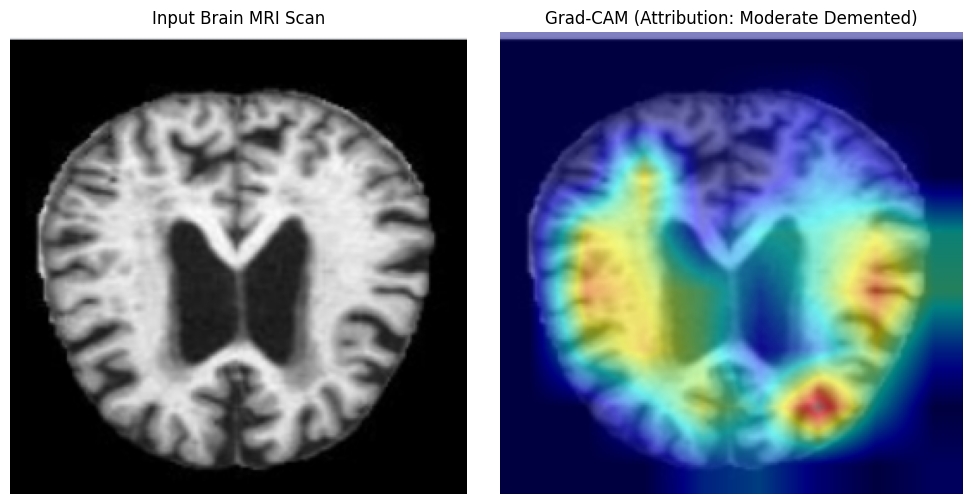



### 🩺 Automated Clinical Decision Support Report
* **Diagnostic Prediction:** Moderate Demented (Confidence: 32.06%)
* **Visual Biomarker Attribution:** Grad-CAM saliency generated on cortical & ventricular regions.

#### 📋 Evidence-Based Next Steps (Retrieved via Neo4j):
* **Recommended Diagnostic Tests:** MMSE Assessment & Caregiver Burden Scale
* **Therapeutic Considerations:** Memantine + Donepezil Combination Therapy
* **⚠️ Critical Safety & Contraindication Warnings:** Cardiac conduction monitoring



In [23]:
import io
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

print("Please select and upload a brain MRI slice (.jpg, .png):")
uploaded = files.upload()

for filename in uploaded.keys():
  # 1. Load image from bytes
  input_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

  # 2. Invoke the LangGraph Multi-Agent Pipeline
  state_input = {"image_input": input_image}
  result = clinical_app.invoke(state_input)

  # 3. Visualize Original vs Explainability Heatmap Side-by-Side
  fig, axes = plt.subplots(1, 2, figsize=(10, 5))

  axes[0].imshow(input_image)
  axes[0].set_title("Input Brain MRI Scan", fontsize=12)
  axes[0].axis("off")

  axes[1].imshow(result["cam_heatmap"])
  axes[1].set_title(
      f"Grad-CAM (Attribution: {result['diagnosis']})", fontsize=12
  )
  axes[1].axis("off")

  plt.tight_layout()
  plt.show()

  # 4. Display the Generated Clinical Support Report
  print("\n" + "=" * 65)
  print(result["final_clinical_report"])
  print("=" * 65)